# EECE 5550 Mobile Robotics — Lab #2

**Name:** Dante Benjamin Cometto

**Date:** 20 MAR 2026

---

## Instructions

- Complete all cells marked with `# TODO`.
- Do **not** rename the classes or functions — the autograder depends on the exact signatures.
- You may add helper functions and additional cells for experimentation.
- Submit this `.ipynb` file to Gradescope. The autograder will convert it automatically.
- All plotting / simulation code should be inside `if __name__ == "__main__":` guards so it does not run during grading.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Ellipse
from scipy.linalg import expm
import os.path as osp

---
# Problem 1 — Extended Kalman Filter

### (e) EKF Implementation

In [3]:
class EKF(object):
    """
    Extended Kalman Filter for 2D localization with range measurements
    to two known landmarks.

    Parameters
    ----------
    dt : float               — time step
    x0 : ndarray (2,1)      — initial state estimate
    P0 : ndarray (2,2)      — initial covariance
    R  : ndarray (2,2)      — process noise covariance
    Q  : ndarray (2,2)      — measurement noise covariance
    landmarks : list of ndarray (2,1)   — landmark positions [l1, l2, l3, ...]
    """

    def __init__(self, dt, x0, P0, R, Q, landmarks):
        self.dt = dt
        self.R = R
        self.Q = Q
        self.I = np.eye(2)
        self.landmarks = [np.array(l).reshape(-1, 1) for l in landmarks]
        self.n = len(self.landmarks)
        self.x = x0.copy()
        self.P = P0.copy()

        self.A = np.eye(2)
        self.B = dt*np.eye(2)

        self.G = np.eye(2)

    def predict(self, v):
        """
        EKF prediction step.

        Parameters
        ----------
        v : array-like (2,1) — velocity command [vx, vy]

        Updates self.x and self.P in place.
        """
        # Implement the EKF predict equations.
        # raise NotImplementedError("Implement EKF.predict")

        self.x = self.A @ self.x + self.B @ v
        self.P = self.G @ self.P @ self.G.T + self.R    # Note: could remove self.G in this case

    def update(self, z):
        """
        EKF measurement update step.

        Parameters
        ----------
        z : ndarray (2,1) — measurement [range_to_l1, range_to_l2]

        Updates self.x and self.P in place.
        """
        # Implement the EKF update equations.
        #   1. Compute predicted ranges: h(x) = 
        #   2. Compute Jacobian H 
        #   3. Kalman gain: K = 
        #   4. State update: x = 
        #   5. Covariance update: P = 
        # self.x =
        # self.P = 
        # raise NotImplementedError("Implement EKF.update")

        h = self._h(self.x, self.landmarks)
        y = z - h

        H = self._H(self.x, self.landmarks)
        S = H @ self.P @ H.T + self.Q
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(2) - K @ H) @ self.P
        
        
    
    @staticmethod
    def _H(x, landmarks):
        """Compute the Jacobian matrix for the measurement model.

        Parameters
        ----------
        x : ndarray (2,1) - Current state estimate
        landmarks : list of ndarray (2,1) - Landmark positions

        Returns
        -------
        H : ndarray (N, 2) - The Jacobian matrix H
        """
        # Compute the Jacobian matrix H for the measurement model.

        d = EKF._h(x,landmarks)

        H = np.zeros((len(landmarks),x.size))
        for i,l in enumerate(landmarks):
            for j in range(x.size):
                H[i,j] = -(l[j,0] - x[j,0])/d[i,0]

        return H

        

    @staticmethod
    def _h(x, landmarks):
        """Compute the predicted measurement.

        Parameters
        ----------
        x : ndarray (2,1) - Current state estimate
        landmarks : list of ndarray (2,1) - Landmark positions

        Returns
        -------
        h : ndarray (N, 1) - The measurement vector h
        """
        h = np.zeros((len(landmarks),1))
        for idx,l in enumerate(landmarks):
            h[idx,0] = np.linalg.norm(l-x)

        return h
    
if __name__ == "__main__":
    x = np.array([0,0]).reshape(-1,1)
    landmarks = [
        np.array([1,0]).reshape(-1,1),
        np.array([1,1]).reshape(-1,1)
    ]

    print(f"shape x: {x.shape}")
    print(f"h: {EKF._h(x,landmarks)}")
    print(f"shape h: {EKF._h(x,landmarks).shape}")
    print(f"H: {EKF._H(x,landmarks)}")

    # Compared with ML: good
    # Also, using real column vectors not 1D arrays

shape x: (2, 1)
h: [[1.        ]
 [1.41421356]]
shape h: (2, 1)
H: [[-1.          0.        ]
 [-0.70710678 -0.70710678]]


In [4]:
def measurement(x, landmarks, Q, nprandom=None):
    """
    Simulate a noisy range measurement to two landmarks.

    Parameters
    ----------
    x  : ndarray (2,1) — true robot position
    landmarks : list of ndarray (2,1) — list of landmark positions
    Q  : ndarray (2,2) — measurement noise covariance

    Returns
    -------
    z : ndarray (2,1)
    """
    # Compute true ranges and add Gaussian noise.
    # raise NotImplementedError("Implement measurement()")
    nprandom = nprandom if nprandom is not None else np.random.default_rng()

    h = np.zeros((len(landmarks),1))
    for idx,l in enumerate(landmarks):
        h[idx,0] = np.linalg.norm(l-x)

    delta = nprandom.multivariate_normal(np.zeros((2,)),Q).reshape(-1,1)
    # print(f"shape delta: {delta.shape}")
    h = h + delta

    return h

def transition(x, v, dt, R, nprandom=None):
    """
    Simulate noisy state transition.

    Parameters
    ----------
    x  : ndarray (2,1)     — current position
    v  : array-like (2,1)   — velocity
    dt : float             — time step
    R  : ndarray (2,2)     — process noise covariance

    Returns
    -------
    x_new : ndarray (2,1)
    """
    # x_new = x + v*dt + noise
    # raise NotImplementedError("Implement transition()")
    nprandom = nprandom if nprandom is not None else np.random.default_rng()

    eps = nprandom.multivariate_normal(np.zeros((2,)),R).reshape(-1,1)
    x = x + v*dt + eps

    return x


if __name__ == "__main__":
    x = np.array([0,0]).reshape(-1,1)
    landmarks = [
        np.array([1,0]).reshape(-1,1),
        np.array([1,1]).reshape(-1,1)
    ]

    R = 0.1 * np.eye(2)
    Q = 0.5 * np.eye(2)

    # nprandom = np.random.default_rng(seed=None)

    # print(f"z: {measurement(x,landmarks,Q,nprandom=nprandom)}")
    # print(f"shape z: {measurement(x,landmarks,Q,nprandom=nprandom).shape}")
    print(f"z: {measurement(x,landmarks,Q)}")
    print(f"shape z: {measurement(x,landmarks,Q).shape}")

    dt = 0.5
    v = np.array([1, 0]).reshape(-1, 1)

    # print(f"x: {transition(x,v,dt,R,nprandom=nprandom)}")
    print(f"x: {transition(x,v,dt,R)}")

    # Looks good

z: [[1.41234663]
 [1.03775473]]
shape z: (2, 1)
x: [[ 0.91533789]
 [-0.37121653]]


In [6]:
def plot_confidence_ellipse(ax, mean, cov, n_sigma=np.sqrt(7.378), **kwargs):
    """Plot an n-sigma confidence ellipse (provided — do not modify)."""
    mean = np.asarray(mean).ravel()
    cov = np.asarray(cov)
    eigvals, eigvecs = np.linalg.eigh(cov)
    width = 2 * n_sigma * np.sqrt(eigvals[0])
    height = 2 * n_sigma * np.sqrt(eigvals[1])
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    ellipse = Ellipse(xy=mean, width=width, height=height,
                      angle=angle,**kwargs)
    ax.add_patch(ellipse)
    return ellipse

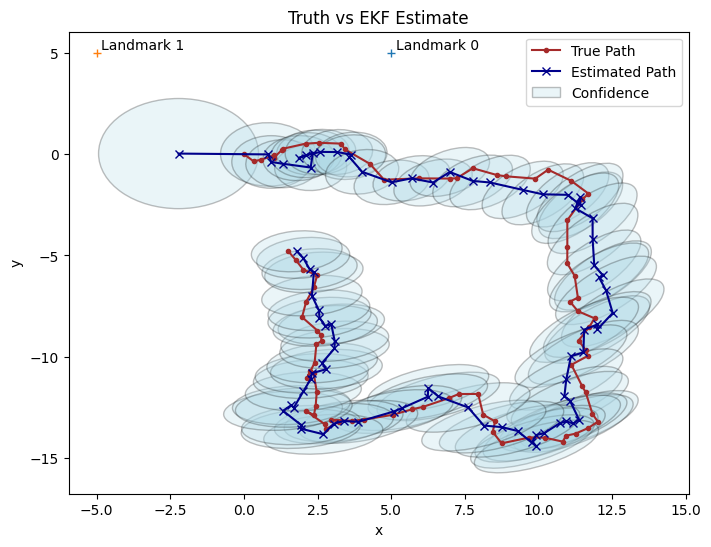

In [7]:
if __name__ == "__main__":
    # ============================================================
    # Problem 1(e): EKF Simulation
    # ============================================================
    seed = 2025
    nprandom = np.random.default_rng(seed=seed)

    l1 = np.array([5, 5]).reshape(-1, 1)
    l2 = np.array([-5, 5]).reshape(-1, 1)
    landmarks = [l1,l2]

    R = 0.1 * np.eye(2) # 0.1
    Q = 0.5 * np.eye(2) # 0.5
    dt = 0.5

    real_x = np.array([0, 0]).reshape(-1, 1)   # true initial position
    x0 = nprandom.multivariate_normal(np.zeros(2), np.eye(2)).reshape(-1, 1)
    P0 = np.eye(2)

    v1 = np.array([1, 0]).reshape(-1, 1)
    v2 = np.array([0, -1]).reshape(-1, 1)
    v3 = np.array([-1, 0]).reshape(-1, 1)
    v4 = np.array([0, 1]).reshape(-1, 1)

    vs = [v1, v2, v3, v4]
    ts = [
        np.arange(0, 10 + dt, dt),
        np.arange(10 + dt, 20 + dt, dt),
        np.arange(20 + dt, 30 + dt, dt),
        np.arange(30 + dt, 40 + dt, dt)
    ]

    # Create EKF, run simulation loop, collect results, and plot.
    #
    # For each (v, t_array) pair:
    #   for t in t_array:
    #       
    # Plot: true positions, EKF estimates, 3-sigma ellipses, landmarks.

    

    # Form estimator
    estimator = EKF(dt,x0,P0,R,Q,landmarks)
    x = real_x
    
    # Loop through simulation
    truexs = [x.reshape((2,))]
    estimatexs = [estimator.x.reshape((2,))]
    covs = [estimator.P]
    for v,tarray in zip(vs,ts):
        
        for t in tarray:
            # Calculate environment
            x = transition(x,v,dt,R,nprandom=nprandom)
            z = measurement(x,landmarks,Q,nprandom=nprandom)

            # Estimate
            estimator.predict(v)
            estimator.update(z)

            # Log
            truexs.append(x.reshape((2,)))
            estimatexs.append(estimator.x.reshape((2,)))
            covs.append(estimator.P)
        
    # Log
    truexs_array = np.array(truexs)
    estimatexs_array = np.array(estimatexs)


    # Plot
    fig,axs = plt.subplots(1,1,figsize=(8,6))
    shift=0.15
    pathcolor = "brown"
    estcolor = "darkblue"


    # print(f"shape: {estimatexs.shape}")

    # Plot landmarks
    for num,l in enumerate(landmarks):
        axs.plot(l[0,0],l[1,0],marker='+')
        axs.annotate(f"Landmark {num}", xy=(l[0,0],l[1,0]), xytext=(l[0,0]+shift,l[1,0]+shift))

    # Plot true xs
    axs.plot(truexs_array[:,0],truexs_array[:,1],color=pathcolor,marker='.',label="True Path")

    # Plot estimate xs
    axs.plot(estimatexs_array[:,0],estimatexs_array[:,1],color=estcolor,marker='x',label="Estimated Path")

    # Plot covariances
    for idx,P in enumerate(covs):
        plot_confidence_ellipse(axs,estimatexs_array[idx,:],P, edgecolor="black",facecolor="lightblue",alpha=0.25,label="Confidence" if idx == 0 else None)

    axs.set_title("Truth vs EKF Estimate")
    axs.set_xlabel("x")
    axs.set_ylabel("y")
    axs.legend()
    plt.show()


---
# Problem 2 — Iterative Closest Point (ICP)

### (a) EstimateCorrespondence

In [101]:
def EstimateCorrespondence(X, Y, t, R, dmax):
    """
    Estimate point correspondences (Algorithm 1, lines 5–10).

    Parameters
    ----------
    X    : ndarray (nX, d) — source pointcloud
    Y    : ndarray (nY, d) — target pointcloud
    t    : ndarray (d, 1)  — current translation estimate
    R    : ndarray (d, d)  — current rotation estimate
    dmax : float           — max distance for correspondence

    Returns
    -------
    C : ndarray (K, 2) — correspondence pairs [(i, j), ...]
    """
    # For each point x_i in X:
    #   1. Compute transformed point: y_hat = R @ x_i + t
    #   2. Find closest point y_j in Y to y_hat
    #   3. If distance < dmax, add (i, j) to C
    # raise NotImplementedError("Implement EstimateCorrespondence")

    num_xpts = X.shape[0]
    num_ypts = Y.shape[0]

    Clist = []

    for i in range(num_xpts):
        x_i = X[i,:].T.reshape(-1,1)
        y_hat = (R @ x_i + t).reshape((3,))
        # print(f"{i} x: {x_i.shape}")
        # print(f"{i} t: {t.shape}")
        # print(f"{i} yhat: {y_hat}")

        # d = np.array([np.linalg.norm(Y[j,:]-y_hat) for j in range(num_ypts)]) # Note: not using squared distance because it doesn't affect and using normal distance later
        d = np.linalg.norm(Y-y_hat,axis=1)
        yjidx = np.argmin(d) # Note: this is always the first min value

        yj = Y[yjidx,:]

        if d[yjidx] < dmax:
            Clist.append((i,yjidx))

        # print(f"{i} x: {x_i}")
        # print(f"{i} d: {d}")
        # print(f"{i} idx: {yjidx}")
        # print(f"{i} yj: {yj}")
        

    return np.array(Clist)

        
    

if __name__ == "__main__":
    X = np.array([
        [0,0,0],
        [1,1,1],
        [1.8,1,1],
        [10,0,0],
    ])

    Y = np.array([
        [0.1, 0, 0],
        [1.2, 1, 1],
        [1.2, 1, 1],
        [1.5, 1, 1],
        [11, 1, 1],
    ])

    R = np.eye(3)
    t = np.zeros((3,1))

    C = EstimateCorrespondence(X,Y,t,R,dmax=0.6)
    print(C)

[[0 0]
 [1 1]
 [2 3]]


### (b) ComputeOptimalRigidRegistration (Horn's Method)

In [106]:
def ComputeOptimalRigidRegistration(X, Y, C):
    """
    Compute optimal (R, t) aligning corresponding points (Algorithm 2).

    Parameters
    ----------
    X : ndarray (nX, d) — source pointcloud
    Y : ndarray (nY, d) — target pointcloud
    C : ndarray (K, 2)  — correspondence pairs

    Returns
    -------
    R : ndarray (d, d) — optimal rotation
    t : ndarray (d, 1) — optimal translation
    """
    # Implement Horn's method (Algorithm 2).
    # raise NotImplementedError("Implement ComputeOptimalRigidRegistration")
    num_C = C.shape[0]
    if not num_C == 0:

        xcentroid = np.mean(X,axis=0)
        ycentroid = np.mean(Y,axis=0)

        xdev = X - xcentroid
        ydev = Y - ycentroid

        W = np.eye(3,3)
        for idx in range(num_C):
            i,j = C[idx,:]
            W += ydev[j,:] @ xdev[i,:].T
        W = 1/num_C * W

        U,S,Vh = np.linalg.svd(W,compute_uv=True)

        R = U @ np.diag([1, 1, np.linalg.det(U @ Vh.T)]) @ Vh
        t = ycentroid - R @ xcentroid

    else:
        R = np.eye(3)
        t = np.zeros((3,1))

    # print(f"xcentroid: {xcentroid}")
    # print(f"xdev: {xdev}")
    # print(f"W: {W}")
    # print(f"R: {R}")
    # print(f"t: {t}")
    # print(f"shape t: {t.shape}")

    return R,t

if __name__ == "__main__":
    X = np.array([
        [2,1,1],
        [1,2,1],
        [1,1,2],
    ])

    theta = 0.1
    R0 = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1],
    ])

    Y = R0 @ X + 0.1

    C = EstimateCorrespondence(X,Y,t,R,dmax=100)
    print(C)

    R,t = ComputeOptimalRigidRegistration(X,Y,C)

    print(f"R: {R} \n t: {t}")

[[0 0]
 [1 1]
 [2 2]]
R: [[ 1.00000000e+00  3.32496497e-16  2.21474195e-16]
 [ 1.86336016e-16  1.00000000e+00 -2.44421732e-16]
 [ 1.86336016e-16 -2.44421732e-16  1.00000000e+00]] 
 t: [0.12828197 0.06172636 0.09666944]


### (c) ICP Algorithm

In [99]:
def SE3_transform(X, R, t):
    """Apply rigid transformation (provided — do not modify)."""
    return (R @ X.T).T + t.T


def RMSE(X, Y, C):
    """Root-mean-squared error for corresponding points (provided — do not modify)."""
    return np.sqrt(np.linalg.norm(X[C[:, 0]] - Y[C[:, 1]], axis=1).mean())

In [100]:
def ICP(X, Y, t0, R0, dmax, num_ICP_iters):
    """
    Iterative Closest Point (Algorithm 1).

    Parameters
    ----------
    X              : ndarray (nX, d) — source pointcloud
    Y              : ndarray (nY, d) — target pointcloud
    t0             : ndarray (d, 1)  — initial translation
    R0             : ndarray (d, d)  — initial rotation
    dmax           : float           — max correspondence distance
    num_ICP_iters  : int             — number of iterations

    Returns
    -------
    R : ndarray (d, d) — estimated rotation
    t : ndarray (d, 1) — estimated translation
    C : ndarray (K, 2) — final correspondences
    """
    # TODO: Implement the ICP loop.
    #   t, R = t0, R0
    #   for each iteration:
    #       C = EstimateCorrespondence(X, Y, t, R, dmax)
    #       R, t = ComputeOptimalRigidRegistration(X, Y, C)
    #       (optionally print RMSE)
    #   return R, t, C
    # raise NotImplementedError("Implement ICP")

    t = t0
    R = R0

    for idx in range(num_ICP_iters):
        C = EstimateCorrespondence(X,Y,t,R,dmax)
        R,t = ComputeOptimalRigidRegistration(X,Y,C)

    return R,t,C


if __name__ == "__main__":
    X = np.array([
        [2,1,1],
        [1,2,1],
        [1,1,2],
    ])

    R0 = np.array([
        [0,-1,0],
        [1,0,0],
        [0,0,1],
    ])

    Y =  R0 @ X + np.array([0.1,0.1,0.1]).T

    R,t,C = ICP(X,Y,np.zeros((3,1)),np.eye(3),100,1000)

    print(f"R: {R} \n t: {t}")

0 d: [4.51995575 0.17320508 1.42478068]
0 idx: 1
0 yj: [2.1 1.1 1.1]
1 d: [4.73603209 1.42478068 1.42478068]
1 idx: 1
1 yj: [2.1 1.1 1.1]
2 d: [4.51995575 1.42478068 0.17320508]
2 idx: 2
2 yj: [1.1 1.1 2.1]
0 d: [3.16227766 1.63299316 2.1602469 ]
0 idx: 1
0 yj: [2.1 1.1 1.1]
1 d: [3.26598632 1.82574186 1.82574186]
1 idx: 2
1 yj: [1.1 1.1 2.1]
2 d: [3.16227766 2.1602469  1.63299316]
2 idx: 2
2 yj: [1.1 1.1 2.1]
0 d: [3.16227766 1.63299316 2.1602469 ]
0 idx: 1
0 yj: [2.1 1.1 1.1]
1 d: [3.26598632 1.82574186 1.82574186]
1 idx: 2
1 yj: [1.1 1.1 2.1]
2 d: [3.16227766 2.1602469  1.63299316]
2 idx: 2
2 yj: [1.1 1.1 2.1]
0 d: [3.16227766 1.63299316 2.1602469 ]
0 idx: 1
0 yj: [2.1 1.1 1.1]
1 d: [3.26598632 1.82574186 1.82574186]
1 idx: 2
1 yj: [1.1 1.1 2.1]
2 d: [3.16227766 2.1602469  1.63299316]
2 idx: 2
2 yj: [1.1 1.1 2.1]
0 d: [3.16227766 1.63299316 2.1602469 ]
0 idx: 1
0 yj: [2.1 1.1 1.1]
1 d: [3.26598632 1.82574186 1.82574186]
1 idx: 2
1 yj: [1.1 1.1 2.1]
2 d: [3.16227766 2.1602469  1.6329

### (d) Apply ICP to 3D Pointclouds

In [84]:
if __name__ == "__main__":
    # Load pointclouds (adjust path if needed)
    pt_cld_X = pd.read_csv(osp.join("data", "pclX.txt"),
                            header=None, names=["X", "Y", "Z"],
                            delimiter=" ").values
    pt_cld_Y = pd.read_csv(osp.join("data", "pclY.txt"),
                            header=None, names=["X", "Y", "Z"],
                            delimiter=" ").values

    print(f"Pointcloud X: {pt_cld_X.shape}")
    print(f"Pointcloud Y: {pt_cld_Y.shape}")

    # TODO: Run ICP with:
    #   R0 = I_3, t0 = 0, dmax = 0.25, num_ICP_iters = 30
    # Report:
    #   - Estimated R and t
    #   - Verify R^T R ≈ I and det(R) ≈ 1
    #   - RMSE
    #   - Plot co-registered pointclouds
    # pass  # Replace with your code

    R,t,C = ICP(pt_cld_X, pt_cld_Y, t0 = np.zeros((3,1)), R0 = np.eye(3), dmax=0.25, num_ICP_iters=1)

Pointcloud X: (5750, 3)
Pointcloud Y: (5750, 3)


KeyboardInterrupt: 

---
# Problem 3 — Particle Filter on SE(2)

### (c)–(d) Particle Filter Implementation

In [11]:
class DifferentialDriveParticleFilter:
    """
    Particle filter for a differential-drive robot on SE(2).

    State: x_t ∈ SE(2), represented as a 3×3 homogeneous matrix.
    Motion: noisy wheel speeds + Lie group exponential map.
    Measurement: noisy measurement position z_t ∈ R².

    Parameters
    ----------
    dt           : float — time step (seconds)
    wheel_radius : float — wheel radius r (meters)
    track_width  : float — track width w (meters)
    cmd_left     : float — commanded left wheel speed (rad/s)
    cmd_right    : float — commanded right wheel speed (rad/s)
    sigma_left   : float — std dev of left wheel noise
    sigma_right  : float — std dev of right wheel noise
    sigma_pos    : float — std dev of measurement noise
    n_particles  : int   — number of particles
    """

    def __init__(self, dt, wheel_radius, track_width,
                 cmd_left, cmd_right,
                 sigma_left, sigma_right,
                 sigma_pos, n_particles):
        self.dt = dt
        self.r = float(wheel_radius)
        self.w = float(track_width)
        self.cmd_left = float(cmd_left)
        self.cmd_right = float(cmd_right)
        self.sigma_left = float(sigma_left)
        self.sigma_right = float(sigma_right)
        self.sigma_pos = float(sigma_pos)
        self.n_particles = n_particles
        self.weights = np.ones(n_particles) / n_particles

    # ------------------------------------------------------------------
    # Helpers
    # ------------------------------------------------------------------

    def _sample_noisy_wheel_speeds(self):
        """
        Sample noisy wheel speeds (equation 13).

        Returns (wl, wr): noisy left and right wheel speeds.
        """
        # TODO: Sample wl and wr from Gaussian distributions centered at cmd_left and cmd_right
        raise NotImplementedError

    @staticmethod
    def _hat_map(wl, wr, r, w):
        """
        Build se(2) Lie algebra element (equation 15).

        Parameters: wl, wr (wheel speeds), r (radius), w (track width)
        Returns: 3x3 ndarray
        """
        # TODO: Implement the hat map to convert wheel speeds to a Lie algebra element.
        raise NotImplementedError

    @staticmethod
    def _extract_position(pose):
        """Extract 2D position from 3×3 SE(2) matrix (provided)."""
        return pose[:2, -1]

    # ------------------------------------------------------------------
    # (c) Propagation
    # ------------------------------------------------------------------

    def propagate(self, particles):
        """
        Particle filter propagation step (Algorithm 3).

        For each particle:
          1. Resample index j from current weights.
          2. Draw noisy wheel speeds.
          3. Build Lie algebra element with _hat_map.
          4. Propagate based on Lie group exponential map.

        Parameters
        ----------
        particles : list of ndarray (3,3)

        Returns
        -------
        new_particles : list of ndarray (3,3)
        """
        # TODO: Implement Algorithm 3.
        raise NotImplementedError("Implement propagate")

    # ------------------------------------------------------------------
    # (d) Measurement update
    # ------------------------------------------------------------------

    def update(self, particles, z):
        """
        Particle filter measurement update (Algorithm 4).

        Parameters
        ----------
        particles : list of ndarray (3,3)
        z         : ndarray (2,) — position measurement [x, y]

        Returns
        -------
        resampled : list of ndarray (3,3)
        """
        # TODO: Implement Algorithm 4.
        #   1. For each particle compute weight based on measurement likelihood p(z | x_i).
        #   2. Normalize weights.
        #   3. Resample with replacement.
        raise NotImplementedError("Implement update")

    # ------------------------------------------------------------------
    # Utilities (provided — do not modify)
    # ------------------------------------------------------------------

    @staticmethod
    def positions_array(particles):
        """Return (N, 2) array of particle positions."""
        return np.array([p[:2, -1] for p in particles])

    @staticmethod
    def print_statistics(positions):
        """Print mean and covariance of particle positions."""
        mean = positions.mean(axis=0)
        cov = np.cov(positions.T)
        fmt = {"float": "{:10.6f}".format}
        print("Mean:")
        print(np.array2string(mean, precision=6,
                              suppress_small=True, formatter=fmt))
        print("\nCovariance:")
        print(np.array2string(cov, precision=6,
                              suppress_small=True, formatter=fmt))

### (e) Single propagation to t = 10

In [12]:
if __name__ == "__main__":
    # Fixed parameters for all of Problem 3
    cmd_left = 1.5
    cmd_right = 2.0
    r = 0.25
    w = 0.5
    sigma_l = 0.05
    sigma_r = 0.05
    sigma_p = 0.10
    n_particles = 1000
    dt_pf = 5.0  # renamed to avoid collision with EKF dt

    # TODO: Part (e)
    # Create PF with dt=10, propagate once from I ∈ SE(2).
    # Report mean/covariance, plot positions.

    pass  # Replace with your code

### (f) Dead reckoning (propagation only) at t ∈ {5, 10, 15, 20}

In [13]:
if __name__ == "__main__":
    # TODO: Part (f)
    # Start from N=1000 copies of I ∈ SE(2).
    # Propagate 4 times (no updates). Report mean/cov each step. Plot.

    pass  # Replace with your code

### (g) Propagation + Measurement updates at t ∈ {5, 10, 15, 20}

In [14]:
if __name__ == "__main__":
    measurements = [
        np.array([1.6561, 1.2847]),
        np.array([1.0505, 3.1059]),
        np.array([-0.9875, 3.2118]),
        np.array([-1.6450, 1.1978]),
    ]

    # TODO: Part (g)
    # Start from N=1000 copies of I ∈ SE(2).
    # Alternate propagation + update for 4 steps.
    # Report mean/cov each step. Plot.

    pass  # Replace with your code

# Bonus Problem

## Range-Based Localization & Geometric Dilution of Precision (GDOP)

### Problem Setup

A robot moves through a 2D environment and estimates its position using **range measurements** to $N$ beacons at known locations $\mathbf{b}_i \in \mathbb{R}^2$. Each measurement is the true Euclidean distance corrupted by Gaussian noise:

$$
z_i = \| \mathbf{x} - \mathbf{b}_i \| + v_i, \quad v_i \sim \mathcal{N}(0, \sigma^2)
$$

where $\mathbf{x} = [x, y]^T$ is the robot's unknown position and $\sigma$ is the range noise standard deviation.

Geometrically, each measurement constrains the robot to lie on an **annular ring** (a noisy circle) centered at beacon $i$. With three or more beacons, the intersection of these rings yields a position estimate. This is also known as triangulation.

## Maximum Likelihood Estimation

Assuming independent measurements, the log-likelihood of position $\mathbf{x}$ given range observations $\mathbf{z} = [z_1, \dots, z_N]^T$ is:

$$
\ell(\mathbf{x}) = -\frac{1}{2\sigma^2} \sum_{i=1}^{N} \left( z_i - \| \mathbf{x} - \mathbf{b}_i \| \right)^2 + \text{const.}
$$

Maximizing this is equivalent to the **nonlinear least squares** problem:

$$
\hat{\mathbf{x}} = \arg\min_{\mathbf{x}} \sum_{i=1}^{N} \left( z_i - \| \mathbf{x} - \mathbf{b}_i \| \right)^2
$$

This is the problem your EKF will solve incrementally.

### Fisher Information and the Cramér-Rao Lower Bound

How well *can* we localize, given a particular beacon geometry? The answer comes from the **Fisher Information Matrix (FIM)**. For more details click [here](https://en.wikipedia.org/wiki/Fisher_information).


Define the range function $h_i(\mathbf{x}) = \| \mathbf{x} - \mathbf{b}_i \|$ and its Jacobian as we saw in the previous problem 1.

$$
\mathbf{J}_i = \frac{\partial h_i}{\partial \mathbf{x}}
$$

The FIM for this particular problem is then:

$$
\mathbf{F} = \frac{1}{\sigma^2} \mathbf{J}^T \mathbf{J}
$$

The **Cramér-Rao Lower Bound (CRLB)** states that for any unbiased estimator $\hat{\mathbf{x}}$:

$$
\text{Cov}(\hat{\mathbf{x}}) \succeq \mathbf{F}^{-1}
$$

No estimator can achieve lower variance than $\mathbf{F}^{-1}$—this is a fundamental limit set by the geometry and noise.

### Geometric Dilution of Precision (GDOP)

The GDOP summarizes the CRLB as a single scalar:

$$
\text{GDOP}(\mathbf{x}) = \sqrt{\text{tr}(\mathbf{F}^{-1})} = \sqrt{\text{tr}\!\left( (\mathbf{J}^T \mathbf{J})^{-1} \right)} \cdot \sigma
$$

**Interpretation:** GDOP is a spatial multiplier on your measurement noise. If $\sigma = 0.3\,\text{m}$ and $\text{GDOP} = 2$, then the best achievable position uncertainty is roughly $0.6\,\text{m}$.

Key properties:
- **Low GDOP** → beacons subtend wide angles to the robot → good localization.
- **High GDOP** → beacons are clustered or collinear → poor localization.
- GDOP depends only on **geometry** (the unit vectors $\mathbf{e}_i$), not on the actual range values.

### Why Geometry Matters

Consider two extreme beacon placements for a robot at the origin:

| Configuration | Unit vectors | $\mathbf{J}^T\mathbf{J}$ | GDOP |
|---|---|---|---|
| Equilateral triangle (120° apart) | Well-spread | $\approx \frac{3}{2}\mathbf{I}$ | Low (optimal) |
| Collinear beacons | All parallel | Singular | $\infty$ (no solution) |

When beacons are collinear, the FIM becomes singular because all unit vectors $\mathbf{e}_i$ lie in the same direction — you have no information in the perpendicular direction.

### Exercise

Use the interactive simulator below to:

1. **Place 3 beacons** and observe the GDOP heatmap.
2. Try placing all 3 along a line — notice the high GDOP (red) everywhere.
3. Spread them into a wide triangle — notice low GDOP (green) inside.
4. Think about: where along the robot's path is localization best? Worst? Why?


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

In [ ]:

WORLD, RES, SIGMA = 50.0, 200, 0.25

def make_path(n=300):
    t = np.linspace(0, 2*np.pi, n)
    return np.column_stack([25.0 + 15*np.sin(t), 25.0 + 4*np.sin(2*t)])

def compute_gdop(beacons):
    beacons = [np.array(b).reshape(-1,1) for b in beacons]

    g = np.full((RES, RES), np.nan)
    for i, y in enumerate(np.linspace(0, WORLD, RES)):
        for j, x in enumerate(np.linspace(0, WORLD, RES)):
            pos = np.array([x, y]).reshape(-1, 1)
            J = EKF._H(pos,beacons)
            F = J.T @ J / SIGMA**2
            if np.linalg.det(F) > 1e-12:
                g[i, j] = np.sqrt(np.trace(np.linalg.inv(F)))
    return g

def path_lc(path, **kw):
    pts = path.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap="plasma", norm=Normalize(0, 1), **kw)
    lc.set_array(np.linspace(0, 1, len(segs)))
    return lc

class Sim:
    def __init__(self):
        self.beacons, self.path = [], make_path()
        self.fig, self.ax = plt.subplots(figsize=(16, 16))
        self.cbar = None
        self.fig.canvas.mpl_connect("button_press_event", self.on_click)
        self.fig.canvas.mpl_connect("key_press_event", self.on_key)
        self._refresh()

    def _refresh(self, gdop=None):
        self.ax.clear()
        if gdop is not None:
            clip = np.clip(gdop, np.nanpercentile(gdop, 2), np.nanpercentile(gdop, 98))
            log_gdop = np.log10(clip)
            img = self.ax.imshow(log_gdop, origin="lower", extent=(0,WORLD,0,WORLD),
                                 cmap="RdYlGn_r", alpha=0.6, interpolation="bilinear")
            try:
                if self.cbar: self.cbar.remove()
            except Exception: pass
            self.cbar = self.fig.colorbar(img, ax=self.ax, shrink=0.75, label="log₁₀(GDOP) — lower=better")
        self.ax.add_collection(path_lc(self.path, linewidth=3, alpha=0.7))
        self.ax.plot(*self.path[0], "ks", ms=10, zorder=5, label="Start")
        self.ax.plot(*self.path[-1], "kD", ms=8, zorder=5, label="End")
        for i, b in enumerate(self.beacons):
            self.ax.plot(*b, "r^", ms=16, mec="k", mew=2, zorder=6)
            self.ax.annotate(f"B{i+1}", b, xytext=(10,10), textcoords="offset points",
                             fontsize=12, fontweight="bold", color="red",
                             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
        rem = 3 - len(self.beacons)
        if rem > 0:
            self.ax.set_title(f"Place {rem} more beacon{'s'*(rem!=1)}...")
        else:
            b_arr = np.array(self.beacons)
            if abs(np.cross(b_arr[1]-b_arr[0], b_arr[2]-b_arr[0])) < 0.5:
                self.ax.set_title("⚠ Nearly collinear!", color="red")
            else:
                self.ax.set_title("GDOP Heatmap | 'c'=clear")
        self.ax.set(xlim=(0,WORLD), ylim=(0,WORLD), aspect="equal", xlabel="X (m)", ylabel="Y (m)")
        self.ax.legend(loc="upper left", fontsize=9)
        self.ax.grid(True, alpha=0.2)
        self.fig.canvas.draw_idle()

    def on_click(self, e):
        if e.inaxes != self.ax or len(self.beacons) >= 3: return
        self.beacons.append([e.xdata, e.ydata])
        self._refresh(gdop=compute_gdop(self.beacons) if len(self.beacons)==3 else None)

    def on_key(self, e):
        if e.key == "c":
            self.beacons = []
            try:
                if self.cbar: self.cbar.remove()
            except Exception: pass
            self.cbar = None
            self._refresh()
        elif e.key == "q":
            plt.close(self.fig)

In [17]:
%matplotlib qt

Sim()

In [18]:
# ---- YOUR ANSWER HERE ----
BEACONS = [
    [2.0, 3.0],
    [2.0, 2.0],
    [3.0, 2.0],
]

Traceback (most recent call last):
  File "c:\Users\lpott\anaconda3\envs\ASD\lib\site-packages\matplotlib\cbook.py", line 298, in process
    func(*args, **kwargs)
  File "C:\Users\lpott\AppData\Local\Temp\ipykernel_75488\2023669315.py", line 71, in on_click
    self._refresh(gdop=compute_gdop(self.beacons) if len(self.beacons)==3 else None)
  File "C:\Users\lpott\AppData\Local\Temp\ipykernel_75488\2023669315.py", line 14, in compute_gdop
    F = J.T @ J / SIGMA**2
AttributeError: 'NoneType' object has no attribute 'T'
